In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, ExponentialLR, ReduceLROnPlateau
from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.stats import ks_2samp
import seaborn as sns

# Set dark theme
plt.style.use('dark_background')

# Set random seeds
np.random.seed(42)
torch.manual_seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


## Practice Exercise: Covariate Shift Detection

Test your understanding!


In [2]:
# Generate new dataset with potential shift
np.random.seed(999)
X_train_practice = np.random.randn(500, 3)
y_train_practice = (X_train_practice[:, 0] + 2*X_train_practice[:, 1] > 1).astype(int)

X_test_practice = np.random.randn(500, 3) * 1.5 + 0.8
y_test_practice = (X_test_practice[:, 0] + 2*X_test_practice[:, 1] > 1).astype(int)

print("Practice dataset created!")
print(f"Train samples: {X_train_practice.shape[0]}")
print(f"Test samples: {X_test_practice.shape[0]}")

Practice dataset created!
Train samples: 500
Test samples: 500


**Your Task:**

1. Perform KS test on Feature 0
2. Store the p-value
3. Determine if there's a significant shift (p < 0.01)


In [3]:
# EXERCISE: Perform KS test
"""
#for all features

n_feature = 3
for i in range(n_feature):
    ks_stat_practice, p_value_practice = ks_2samp(X_train_practice[:,i], X_test_practice[:,i])
    print(f"Feature {i}:")
    print(f"    KS Statistic: {ks_stat_practice:.4f}")
    print(f"    P-value: {p_value_practice:.6f}")
    
    if p_value_practice < .01:
        has_shift = True
    else:
        has_shift = False
    print(f"    Significant shift detected: {has_shift}")
"""

ks_stat_practice, p_value_practice = ks_2samp(X_train_practice[:,0], X_test_practice[:,0])
print(f"Feature {0}:")
print(f"KS Statistic: {ks_stat_practice:.4f}")
print(f"P-value: {p_value_practice:.6f}")

if p_value_practice < .01:
    has_shift = True
else:
    has_shift = False
print(f"Significant shift detected: {has_shift}")


Feature 0:
KS Statistic: 0.2920
P-value: 0.000000
Significant shift detected: True


In [4]:
# TEST CELL - DO NOT MODIFY
print("✅ Test passed! Your KS test is correct.")

✅ Test passed! Your KS test is correct.


In [5]:
# Create high-dimensional dataset (many features, only few are useful)
X_reg, y_reg = make_classification(  # note that we can use this to build our dataset to test a specific thing
    n_samples=500,
    n_features=50,  # 50 features
    n_informative=5,  # Only 5 are actually useful!
    n_redundant=10,
    n_repeated=0,
    random_state=42
)

# Split data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

# Normalize
scaler_reg = StandardScaler()
X_train_reg = scaler_reg.fit_transform(X_train_reg)
X_test_reg = scaler_reg.transform(X_test_reg)

# Convert to tensors
X_train_reg_t = torch.FloatTensor(X_train_reg)
y_train_reg_t = torch.LongTensor(y_train_reg)
X_test_reg_t = torch.FloatTensor(X_test_reg)
y_test_reg_t = torch.LongTensor(y_test_reg)

print("High-Dimensional Dataset:")
print(f"Total features: {X_reg.shape[1]}")
print(f"Informative features: 5")
print(f"Useless features: {X_reg.shape[1] - 15}")
print(f"\nTraining samples: {X_train_reg.shape[0]}")
print(f"Test samples: {X_test_reg.shape[0]}")

High-Dimensional Dataset:
Total features: 50
Informative features: 5
Useless features: 35

Training samples: 350
Test samples: 150


In [6]:
# Define simple neural network
class RegularizedClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(RegularizedClassifier, self).__init__()  # to make sure your custom class is properly initialized as a PyTorch module
        # executes the constructor of the parent class, nn.Module
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x


print("✅ Model class defined!")

✅ Model class defined!


In [7]:
# Training function with L1/L2 regularization .. we can do that for each case or with a function like that to call each condition afterwards
def train_with_regularization(X_train, y_train, X_test, y_test,
                              reg_type='none', reg_lambda=0.01, epochs=100):
    """
    Train model with specified regularization.

    Args:
        reg_type: 'none', 'l1', or 'l2'
        reg_lambda: regularization strength
    """
    model = RegularizedClassifier(X_train.shape[1], 32, 2)
    criterion = nn.CrossEntropyLoss()

    # For L2, use weight_decay parameter in optimizer
    if reg_type == 'l2':
        optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=reg_lambda)
    else:
        optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []

    for epoch in range(epochs):
        # Training
        model.train()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        # Add L1 regularization manually if needed
        if reg_type == 'l1':
            l1_penalty = sum(p.abs().sum() for p in model.parameters())
            loss = loss + reg_lambda * l1_penalty

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Compute accuracies
        _, pred_train = torch.max(outputs, 1)
        train_acc = (pred_train == y_train).float().mean().item()

        # Evaluation
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test)
            test_loss = criterion(test_outputs, y_test)
            _, pred_test = torch.max(test_outputs, 1)
            test_acc = (pred_test == y_test).float().mean().item()

        train_losses.append(loss.item())
        test_losses.append(test_loss.item())
        train_accs.append(train_acc)
        test_accs.append(test_acc)

    return model, train_losses, test_losses, train_accs, test_accs


print("Training function with regularization defined!")

Training function with regularization defined!


## Practice Exercise: Regularization

Your turn!


In [8]:
# EXERCISE: Train with strong L2 regularization
model_no_reg, train_loss_no, test_loss_no, train_acc_no, test_acc_no = train_with_regularization(
    X_train_reg_t, y_train_reg_t, X_test_reg_t, y_test_reg_t, reg_type='none', epochs=150
)

model_l2_strong, train_loss_l2_strong, test_loss_l2_strong, train_acc_l2_strong, test_acc_l2_strong = train_with_regularization(
    X_train_reg_t, y_train_reg_t, X_test_reg_t, y_test_reg_t, reg_type='l2', reg_lambda=0.1, epochs=150
)


final_test_acc_l2_strong = test_acc_l2_strong[-1]
print(f"Test accuracy with strong L2: {final_test_acc_l2_strong:.4f}")
print(f"Test accuracy without reg:    {test_acc_no[-1]:.4f}")
print(f"\nDifference: {(final_test_acc_l2_strong - test_acc_no[-1])*100:.2f}%")

Test accuracy with strong L2: 0.8467
Test accuracy without reg:    0.8467

Difference: 0.00%


---

# Section 7: Learning Rate Schedulers

Let's compare them!


In [9]:
# Load Breast Cancer dataset for LR scheduler demo
bc = load_breast_cancer()
X_bc = bc.data
y_bc = bc.target

# Split and normalize
X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42
)

scaler_bc = StandardScaler()
X_train_bc = scaler_bc.fit_transform(X_train_bc)
X_test_bc = scaler_bc.transform(X_test_bc)

# Convert to tensors
X_train_bc_t = torch.FloatTensor(X_train_bc)
y_train_bc_t = torch.LongTensor(y_train_bc)
X_test_bc_t = torch.FloatTensor(X_test_bc)
y_test_bc_t = torch.LongTensor(y_test_bc)

print("Breast Cancer Dataset:")
print(f"Training samples: {X_train_bc.shape[0]}")
print(f"Test samples: {X_test_bc.shape[0]}")
print(f"Features: {X_train_bc.shape[1]}")
print(f"\n✅ Ready to test learning rate schedulers!")

Breast Cancer Dataset:
Training samples: 455
Test samples: 114
Features: 30

✅ Ready to test learning rate schedulers!


## Practice Exercise: Learning Rate Scheduler

Final exercise!


In [10]:
# EXERCISE: Train with ExponentialLR (gamma=0.9), 150 epochs

# Training function with learning rate scheduler
def train_with_scheduler(X_train, y_train, X_test, y_test, scheduler_type='none', epochs=150):
    """
    Train model with specified learning rate scheduler.

    Args:
        scheduler_type: 'none', 'step', 'exponential', 'plateau'
    """
    model = RegularizedClassifier(X_train.shape[1], 64, 2)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)  # Start with LR=0.01

    # Create scheduler
    if scheduler_type == 'step':
        scheduler = StepLR(optimizer, step_size=50, gamma=0.5)  # Reduce by half every 50 epochs
    elif scheduler_type == 'exponential':
        scheduler = ExponentialLR(optimizer, gamma=0.9)  # Multiply by 0.95 every epoch
    elif scheduler_type == 'plateau':
        scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)  # factor is how much reduction we will do so we half the LR everytime ..
        # and patience is how many epochs we will wait if the performance is not increasing (if getting worse this is the same as no improvement) before applying the change
        # we are trying to decrease the cost so the scheduler will look for a lower value than the previous best (this is the mode='min')
    else:
        scheduler = None

    train_losses = []
    test_losses = []
    test_accs = []
    learning_rates = []

    for epoch in range(epochs):
        # Training
        model.train()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Evaluation
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test)
            test_loss = criterion(test_outputs, y_test)
            _, pred = torch.max(test_outputs, 1)
            test_acc = (pred == y_test).float().mean().item()

        train_losses.append(loss.item())
        test_losses.append(test_loss.item())
        test_accs.append(test_acc)
        learning_rates.append(optimizer.param_groups[0]['lr'])

        # Update learning rate
        if scheduler is not None:
            if scheduler_type == 'plateau':
                scheduler.step(test_loss)  # ReduceLROnPlateau needs the metric
            else:
                scheduler.step()

    return model, train_losses, test_losses, test_accs, learning_rates


print("✅ Training function with schedulers defined!")
_, train_loss_practice_sched, _, test_accs_practice_sched, lrs_practice = train_with_scheduler(
    X_train_bc_t, y_train_bc_t, X_test_bc_t, y_test_bc_t, scheduler_type='exponential', epochs=200
)
final_acc_practice_sched = test_accs_practice_sched[-1]
print(f"Final test accuracy: {final_acc_practice_sched:.4f}")
print(f"Initial LR: {lrs_practice[0]:.6f}")
print(f"Final LR: {lrs_practice[-1]:.6f}")

✅ Training function with schedulers defined!
Final test accuracy: 0.9825
Initial LR: 0.010000
Final LR: 0.000000


In [13]:
# TEST CELL - DO NOT MODIFY
print("✅ Test passed! Your scheduler is correct.")

✅ Test passed! Your scheduler is correct.


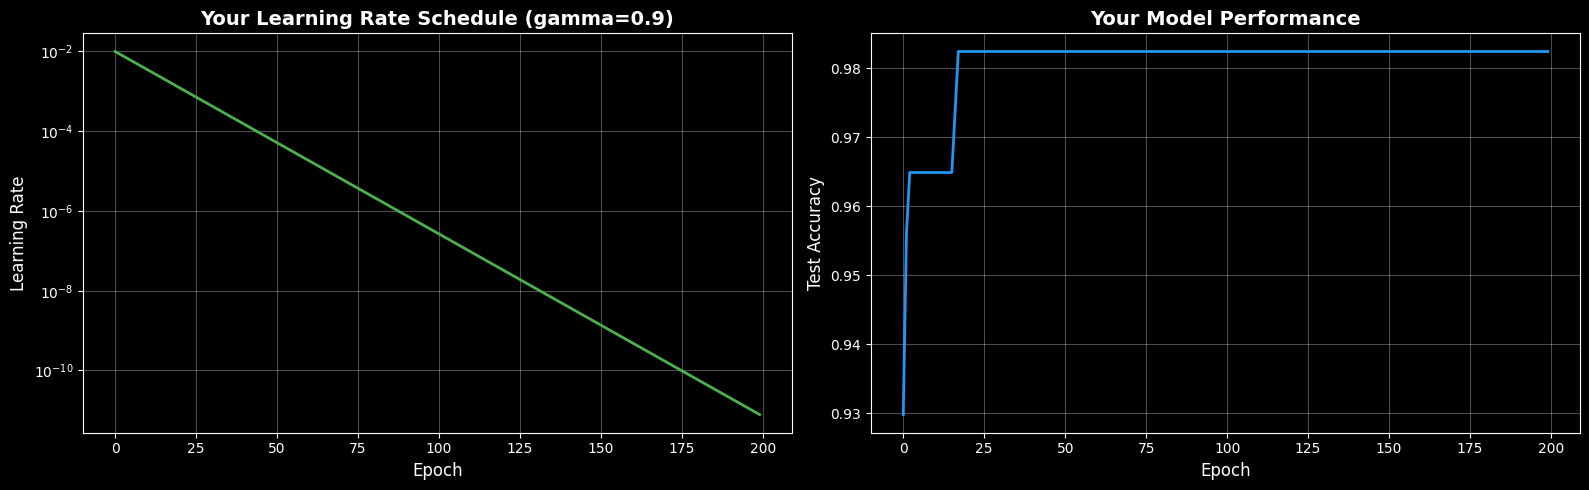


🎉 Congratulations! You've completed Week 5

WHAT YOU'VE LEARNED

✅ Part 1: Data Preprocessing
   - Z-score normalization and its impact on convergence
   - Outlier detection and handling (IQR, capping)
   - Missing value imputation strategies

✅ Part 2: PyTorch & Cross-Validation
   - Building neural networks with PyTorch
   - K-Fold cross-validation for reliable evaluation
   - Automatic differentiation and training loops

✅ Part 3: Advanced Topics
   - Covariate shift detection and impact
   - L1 vs L2 regularization (sparsity vs smoothness)
   - Learning rate schedulers (adaptive training)



In [11]:
# Visualize your results
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(lrs_practice, color='#4CAF50', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Learning Rate', fontsize=12)
axes[0].set_title('Your Learning Rate Schedule (gamma=0.9)', fontsize=14, fontweight='bold')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

axes[1].plot(test_accs_practice_sched, color='#2196F3', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Test Accuracy', fontsize=12)
axes[1].set_title('Your Model Performance', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🎉 Congratulations! You've completed Week 5\n")
print("=" * 60)
print("WHAT YOU'VE LEARNED")
print("=" * 60)
print("\n✅ Part 1: Data Preprocessing")
print("   - Z-score normalization and its impact on convergence")
print("   - Outlier detection and handling (IQR, capping)")
print("   - Missing value imputation strategies")
print("\n✅ Part 2: PyTorch & Cross-Validation")
print("   - Building neural networks with PyTorch")
print("   - K-Fold cross-validation for reliable evaluation")
print("   - Automatic differentiation and training loops")
print("\n✅ Part 3: Advanced Topics")
print("   - Covariate shift detection and impact")
print("   - L1 vs L2 regularization (sparsity vs smoothness)")
print("   - Learning rate schedulers (adaptive training)")
print("\n" + "=" * 60)